In [101]:
import numpy as np
import struct
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.metrics import pairwise_distances_argmin_min
import pandas as pd

In [2]:
# read code from https://www.kaggle.com/code/lavinialei/mnist-mlp-neural-network-2026
def read_idx_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        return images.reshape(num, rows, cols)

def read_idx_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

In [3]:
X_train = read_idx_images("archive/train-images.idx3-ubyte")
y_train = read_idx_labels("archive/train-labels.idx1-ubyte")

X_test = read_idx_images("archive/t10k-images.idx3-ubyte")
y_test = read_idx_labels("archive/t10k-labels.idx1-ubyte")


X_test_flat = X_test.reshape(len(X_test), -1)
X_train_flat = X_train.reshape(len(X_train), -1)
print(X_test_flat.shape)

(10000, 784)


In [4]:
def random_prototype(M):
    indices = np.random.choice(X_train_flat.shape[0], M, replace=False)
    return X_train_flat[indices, :], y_train[indices]


In [8]:
def kmeans_points(X, k):
    kmeans = KMeans(n_clusters=k, init='k-means++').fit(X)
    closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X)
    return closest
def cluster_prototype(M):
    prototypes_X = []
    prototypes_y = []
    k = M // 10
    for i in range(10):
        idx = np.where(y_train == i)[0]
        X_c = X_train_flat[idx]
        centers = kmeans_points(X_c, k)
        prototypes_X.append(X_c[centers])
        prototypes_y.append(np.full(k, i))
    return np.vstack(prototypes_X), np.concatenate(prototypes_y)

In [78]:
def compare(M: int, trials: int):
    neigh = KNeighborsClassifier(n_neighbors=1)

    rand_err = 0
    for trial in range(trials):
        rand_X, rand_y = random_prototype(M)
        neigh.fit(rand_X, rand_y)
        preds = neigh.predict(rand_X)
        rand_err += accuracy_score(y_test, preds)
    print(f"rand_err: {1 - (rand_err / trials)}")
    my_X, my_y = cluster_prototype(M)
    neigh.fit(my_X, my_y)
    preds = neigh.predict(my_X)
    err = 1 - accuracy_score(y_test, preds)
    print(f"my_err: {1 - err}")


In [98]:
neigh = KNeighborsClassifier(n_neighbors=1)
random_1000 = []
for i in range(20):
    rand_X, rand_y = random_prototype(1000)
    neigh.fit(rand_X,rand_y)
    preds = neigh.predict(X_test_flat)
    err = 1 - accuracy_score(y_test,preds)
    random_1000.append(err)
print(np.mean(random_1000))

0.114595


In [44]:
my_10000 = []
for i in range(20):
    neigh = KNeighborsClassifier(n_neighbors=1)
    my_X, my_y = cluster_prototype(10000)
    neigh.fit(my_X,my_y)
    preds = neigh.predict(X_test_flat)
    err = 1 - accuracy_score(y_test,preds)
    my_10000.append(err)
print(np.mean(my_10000))

0.044595


In [81]:
my_records = []
def add_results(errors, M):
    for error in errors:
        my_records.append({"M": M, "error": error})
add_results(my_100, 100)
add_results(my_1000, 1000)
add_results(my_2500, 2500)
add_results(my_5000, 5000)
add_results(my_7500, 7500)
add_results(my_10000,10000)

In [83]:
my_df = pd.DataFrame(my_records)

In [90]:
def confidence(errors):
    n = len(errors)
    mean = np.mean(errors)
    std = np.std(errors, ddof=1)
    se = std / np.sqrt(n)
    tval = 1.96
    return pd.Series({"mean": mean, "confidence": tval * se})

In [85]:
rand_summary = (
    random_df.groupby("M")["error"].apply(confidence).unstack().reset_index()
)
my_summary = (
    my_df.groupby("M")["error"].apply(confidence).unstack().reset_index()
)

In [92]:
rand_summary

,M,mean,confidence
0,100,0.293095,0.008196
1,1000,0.114070,0.001588
2,2500,0.082640,0.001140
3,5000,0.064485,0.000965
4,7500,0.056305,0.000828
5,10000,0.051540,0.000995


In [87]:
my_summary

,M,mean,confidence
0,100,0.133970,0.001290
1,1000,0.072405,0.001268
2,2500,0.058160,0.000730
3,5000,0.050540,0.000656
4,7500,0.046690,0.000603
5,10000,0.044595,0.000472


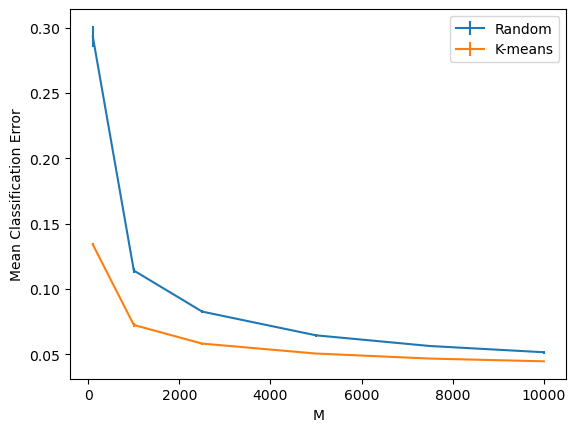

In [100]:
import matplotlib.pyplot as plt
plt.errorbar(rand_summary["M"], rand_summary["mean"], yerr=rand_summary["confidence"], label="Random")
plt.errorbar(my_summary["M"], my_summary["mean"], yerr=my_summary["confidence"], label="K-means")
plt.xlabel("M")
plt.ylabel("Mean Classification Error")
plt.legend()

plt.show()

In [97]:
mean_series = (my_summary["mean"] - rand_summary["mean"]) / rand_summary["mean"]
mean_series.mean()

np.float64(-0.28769389718714344)